<a href="https://colab.research.google.com/github/musowjanya/DL_Mini_Projects/blob/main/computerVision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import load_digits

In [ ]:
dt=load_digits(n_class=3)

In [ ]:
images=dt.images

In [ ]:
Y=dt.target

In [ ]:
images[-2]

array([[ 0.,  0., 15., 13.,  1.,  0.,  0.,  0.],
       [ 0.,  0., 14., 14.,  4.,  0.,  0.,  0.],
       [ 0.,  0.,  1.,  4., 12.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  6., 12.,  0.,  0.,  0.],
       [ 0.,  0.,  0., 11., 10.,  0.,  0.,  0.],
       [ 0.,  0.,  1., 16.,  8.,  6.,  5.,  0.],
       [ 0.,  0., 13., 16., 16., 16., 14.,  0.],
       [ 0.,  0., 10., 13., 10.,  6.,  2.,  0.]])

In [ ]:
Y[-2]

np.int64(2)

In [ ]:
images[0].reshape(1,64)

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
        15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
        12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
         0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
        10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

In [ ]:
images.shape

(537, 8, 8)

In [ ]:
X=images.reshape(-1,64)

In [ ]:
X.shape

(537, 64)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
X = torch.FloatTensor(X)
Y = torch.LongTensor(Y)

In [ ]:
model = nn.Sequential(
    nn.Linear(64, 128),
    nn.ReLU(),

    nn.Linear(128, 64),
    nn.ReLU(),

    nn.Linear(64, 32),
    nn.ReLU(),

    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 32)
)

In [ ]:
# model(X)

In [ ]:
# nn.NLLLoss()

In [ ]:
lossfn = nn.CrossEntropyLoss()

In [ ]:
opt = optim.Adam(model.parameters(), lr=0.01)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader
dataset = TensorDataset(X, Y)

In [ ]:
loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [ ]:
model.train()
# for _ in range(100):
#     opt.zero_grad()
#     Yp = model(X)
#     loss = lossfn(Yp, Y)
#     loss.backward()
#     opt.step()
#     print(loss)
dataset = TensorDataset(X, Y)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

for epoch in range(200):
    for xb, yb in loader:
        opt.zero_grad()
        Yp = model(xb)
        loss = lossfn(Yp, yb)
        loss.backward()
        opt.step()

In [ ]:
model(X)

tensor([[ 41.9129,  -3.1171,   9.9458,  ...,  -7.0374, -40.3930,  -3.4162],
        [  3.1349,  35.4375,  10.4808,  ..., -16.8712, -21.6411,   0.3964],
        [  9.4045,   7.7114,  27.9011,  ...,  -7.3987, -30.8987,   4.5593],
        ...,
        [ 11.9935,   8.2535,  39.3243,  ...,  -8.5526, -41.5855,   6.1835],
        [  8.9686,   7.6585,  29.1745,  ...,  -7.0536, -31.7239,   4.6394],
        [ 47.4991,  -3.1008,  11.4080,  ...,  -8.4782, -45.7713,  -4.0923]],
       grad_fn=<AddmmBackward0>)

In [ ]:
!pip install opencv-python

In [ ]:
import cv2

In [ ]:
ar=cv2.imread('/content/image zero.png')

In [ ]:
ar.shape

(201, 251, 3)

In [ ]:
grar=cv2.cvtColor(ar,cv2.COLOR_BGR2GRAY)

In [ ]:
rszar=cv2.resize(grar,(8,8))

In [ ]:
far=rszar.reshape(1,64)

In [ ]:
far

array([[255, 255, 255, 236, 252, 255, 255, 255, 255, 255,   8, 255, 137,
        255, 255, 255, 255, 255,   0, 255, 255,   0, 255, 255, 255, 255,
          0, 255, 255,   0, 255, 255, 255, 255,   0, 255, 255,   0, 255,
        255, 255, 255,   0, 255, 255,   0, 255, 255, 255, 255, 255,   0,
          0, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255]],
      dtype=uint8)

In [ ]:
fimg=torch.FloatTensor(far)

In [ ]:
model(fimg)

tensor([[  3475.4922,   6280.9438,  11514.1729,  -8152.3491, -10062.1973,
          -6826.0098,  -2987.5620,  -6482.5425,  -4707.1562, -12453.9756,
          -7729.2954,  -9429.0557,  -5967.3740,  -5338.7583,  -6013.4497,
          -8122.0938,  -6963.9038,  -8352.9219,  -5303.0327,  -6151.7622,
          -7489.4404, -10567.3193,  -5015.1558,  -7193.9517,  -3235.8918,
          -5296.3687,  -9004.8730,  -7575.0352,  -6178.6436,  -3853.5364,
         -13581.0898,   1853.6785]], grad_fn=<AddmmBackward0>)

In [ ]:
sfx=torch.softmax(model(fimg),dim=1)

In [ ]:
torch.argmax(sfx,dim=1)

tensor([2])

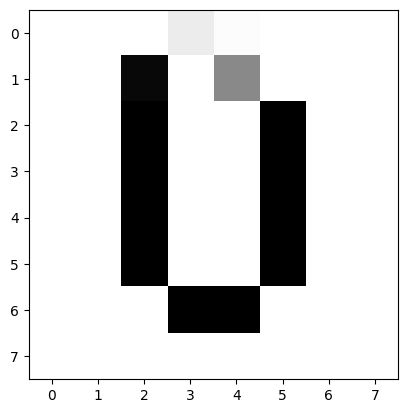

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(rszar, cmap='gray')
plt.show()